# Autoencoder Modelling for Electron $p_T$ Recovery

This notebook trains autoencoders and variational autoencoders (VAE) to recover the original electron $p_T$ distribution from compressed ATLAS DAOD_PHYSLITE files. It includes data loading, normalization, model definition, training, and evaluation.

## 1. Data Loading

Load electron $p_T$ arrays from original and compressed ROOT files.

In [13]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

import matplotlib.pyplot as plt
import uproot
import awkward as ak
from IPython.display import clear_output
import os

# Directories
paths = [
    "~/data/ATLAS/compressed_files/real",
    "~/data/ATLAS/original_files/real"
]

first_files = {}
for p in paths:
    full_path = os.path.expanduser(p)  # expands '~' to your home directory
    files = sorted(os.listdir(full_path))  # sorted so it's deterministic
    if files:  # check not empty
        first_files[p] = os.path.join(full_path, files[0])
    else:
        first_files[p] = None  # or raise an error

# Load compressed
tree_comp = uproot.open({first_files[paths[0]]: "CollectionTree"})
el_pt_comp = tree_comp["AnalysisElectronsAuxDyn.pt"].array()
compressed = ak.flatten(el_pt_comp).to_numpy()
print(first_files)

# Load original
tree_orig = uproot.open({first_files[paths[1]]: "CollectionTree"})
el_pt_orig = tree_orig["AnalysisElectronsAuxDyn.pt"].array()
original = ak.flatten(el_pt_orig).to_numpy()

print(f'Original: {len(original):,} electrons')
print(f'Compressed: {len(compressed):,} electrons')

x_source = compressed.reshape(-1, 1)  # shape (N,1)
x_target = original.reshape(-1, 1)

# x_source_tensor = torch.tensor(x_source, dtype=torch.float32)
# x_target_tensor = torch.tensor(x_target, dtype=torch.float32)

# dataset = TensorDataset(x_source_tensor, x_target_tensor)
# dataloader = DataLoader(dataset, batch_size=128, shuffle=True)


{'~/data/ATLAS/compressed_files/real': '/home/kanbina/data/ATLAS/compressed_files/real/DAOD_PHYSLITE.41578717._000256.pool.root_dl10_compressed.root', '~/data/ATLAS/original_files/real': '/home/kanbina/data/ATLAS/original_files/real/DAOD_PHYSLITE.41578717._000256.pool.root.1'}
Original: 10,019 electrons
Compressed: 10,019 electrons


## 2. Outlier Removal and Normalization

Remove outliers and normalize the data for stable training.

In [2]:
# Set percentile threshold for outlier removal (e.g., 99.9%)
pct_threshold = 99.9

# Compute thresholds on source and target separately
src_max = np.percentile(x_source, pct_threshold)
tgt_max = np.percentile(x_target, pct_threshold)

# Choose a shared max threshold (optional: take the min or max)
max_threshold = min(src_max, tgt_max)

# Filter data to remove outliers beyond max_threshold
mask = (x_source <= max_threshold) & (x_target <= max_threshold)

x_source_clean = x_source[mask]
x_target_clean = x_target[mask]

print(f"Removed {len(x_source) - len(x_source_clean)} outliers")

mean_src = x_source_clean.mean()
std_src = x_source_clean.std()

mean_tgt = x_target_clean.mean()
std_tgt = x_target_clean.std()

x_source_norm = (x_source_clean - mean_src) / std_src
x_target_norm = (x_target_clean - mean_tgt) / std_tgt


import torch
from torch.utils.data import TensorDataset, DataLoader

x_source_tensor = torch.tensor(x_source_norm.reshape(-1, 1), dtype=torch.float32)
x_target_tensor = torch.tensor(x_target_norm.reshape(-1, 1), dtype=torch.float32)

dataset = TensorDataset(x_source_tensor, x_target_tensor)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)


Removed 11 outliers


## 3. Model Definitions

Define the 1D autoencoder and variational autoencoder architectures.

In [3]:
class Autoencoder1D(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon


class VAE1D(nn.Module):
    def __init__(self, hidden_dim=32, latent_dim=8):
        super().__init__()
        # Encoder layers
        self.fc1 = nn.Linear(1, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)

        # Latent parameters
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        # Decoder layers
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, 1)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std  # z ~ N(mu, sigma)

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return self.fc4(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    # KL divergence between posterior N(mu, σ^2) and N(0,1)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss.item(), kl_loss.item()


## 4. Autoencoder Training

Train the autoencoder to map compressed values to original values.

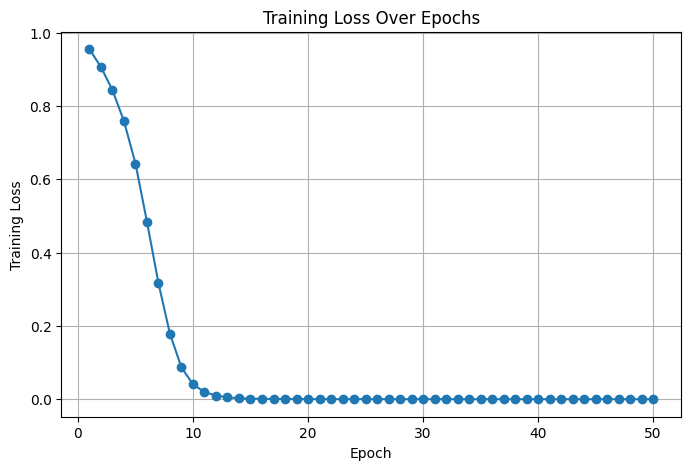

Epoch 50/50, Loss: 0.000016


In [4]:
model = Autoencoder1D()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

losses = []

n_epochs = 50
for epoch in range(n_epochs):
    total_loss = 0
    for x_src, x_tgt in dataloader:
        pred = model(x_src)
        loss = criterion(pred, x_tgt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x_src)

    avg_loss = total_loss / len(dataset)
    losses.append(avg_loss)

    # Clear previous output and plot updated loss
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Over Epochs')
    plt.grid(True)
    plt.show()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")

## 5. Variational Autoencoder (VAE) Training

Train the VAE and monitor reconstruction and KL losses.

In [5]:
# model = VAE1D()
# optimizer = optim.Adam(model.parameters(), lr=1e-4)

# losses = []
# recon_losses = []
# kl_losses = []

# n_epochs = 50
# for epoch in range(n_epochs):
#     total_loss = 0
#     total_recon = 0
#     total_kl = 0

#     for x_src, x_tgt in dataloader:
#         recon, mu, logvar = model(x_src)
#         loss, recon_l, kl_l = vae_loss_function(recon, x_tgt, mu, logvar)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item() * len(x_src)
#         total_recon += recon_l * len(x_src)
#         total_kl += kl_l * len(x_src)

#     avg_loss = total_loss / len(dataset)
#     avg_recon = total_recon / len(dataset)
#     avg_kl = total_kl / len(dataset)

#     losses.append(avg_loss)
#     recon_losses.append(avg_recon)
#     kl_losses.append(avg_kl)

#     # Live plotting
#     clear_output(wait=True)
#     plt.figure(figsize=(10, 5))
#     plt.plot(range(1, len(losses)+1), losses, label='Total Loss', marker='o')
#     plt.plot(range(1, len(losses)+1), recon_losses, label='Reconstruction Loss')
#     plt.plot(range(1, len(losses)+1), kl_losses, label='KL Divergence')
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.title("VAE Training Loss Over Epochs")
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

#     print(f"Epoch {epoch+1}/{n_epochs} | Total: {avg_loss:.6f} | Recon: {avg_recon:.6f} | KL: {avg_kl:.6f}")


## 6. Evaluation and Visualization

Visualize the recovered distribution and compare to the original and compressed distributions.

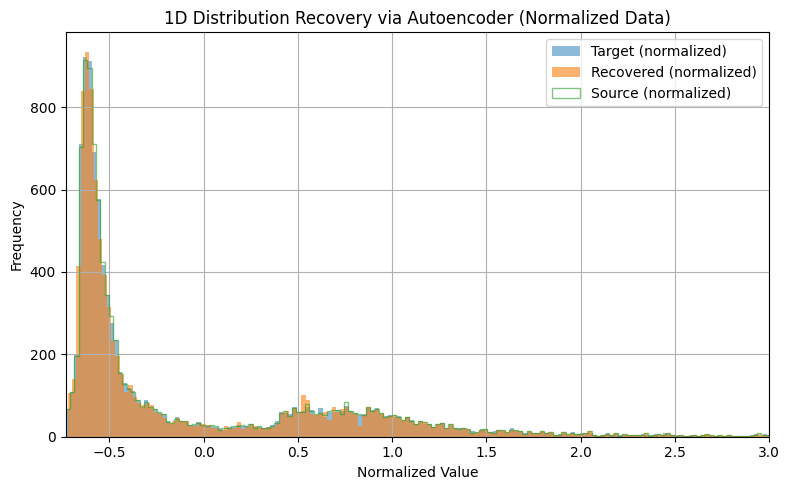

In [6]:
model.eval()
with torch.no_grad():
    recovered_norm = model(x_source_tensor)
recovered_norm = recovered_norm.numpy()

plt.figure(figsize=(8, 5))
plt.hist(x_target_norm, bins=500, alpha=0.5, label="Target (normalized)")
plt.hist(recovered_norm, bins=500, alpha=0.6, label="Recovered (normalized)")
plt.hist(x_source_norm, bins=500, alpha=0.6, label="Source (normalized)", histtype='step')
plt.legend()
plt.title("1D Distribution Recovery via Autoencoder (Normalized Data)")
plt.xlabel("Normalized Value")
plt.ylabel("Frequency")
# plt.xlim(x_target_norm.min(), x_target_norm.max())  # Adjust if needed, or use fixed like (-3, 3)
plt.xlim(x_target_norm.min(), 3)  # Adjust if needed, or use fixed like (-3, 3)

# plt.xlim(x_target_norm.min(), x_target_norm.max())  # Adjust if needed, or use fixed like (-3, 3)
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_455812/1305478179.py:9: UserWarning: Using a target size (torch.Size([10008, 1])) that is different to the input size (torch.Size([10008])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(torch.log(y + eps), torch.log(yhat + eps))


MSE (Target vs Source): 2.747045e-06
MSE (Target vs Recovered): 2.181172e+00


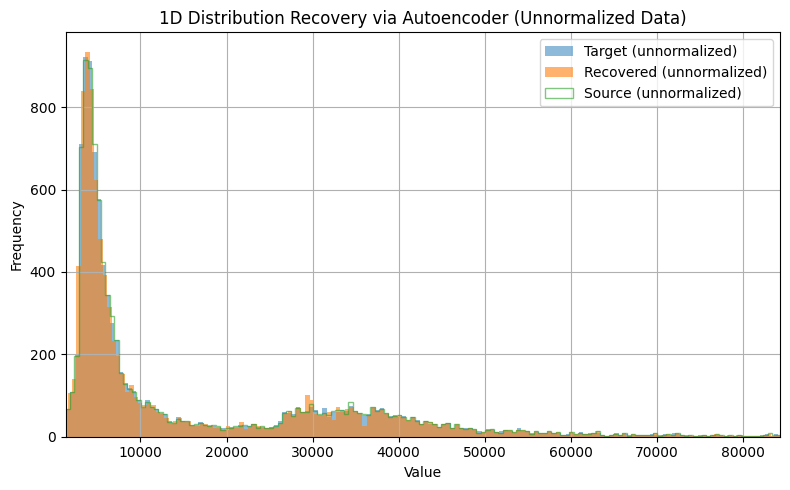

<string>:6: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)
<string>:7: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)
<string>:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


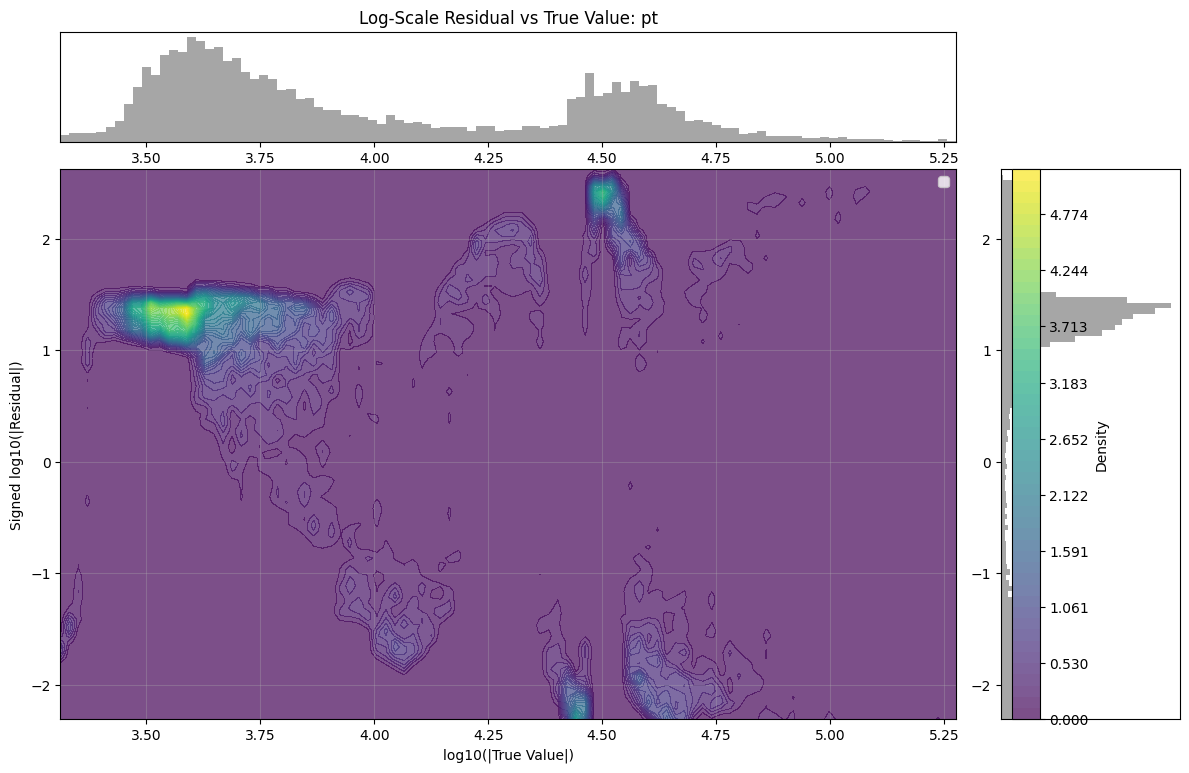

/tmp/ipykernel_455812/1305478179.py:49: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x_target_arr = np.array(x_target).reshape(-1)
/tmp/ipykernel_455812/1305478179.py:50: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  recovered_arr = np.array(recovered).reshape(-1)


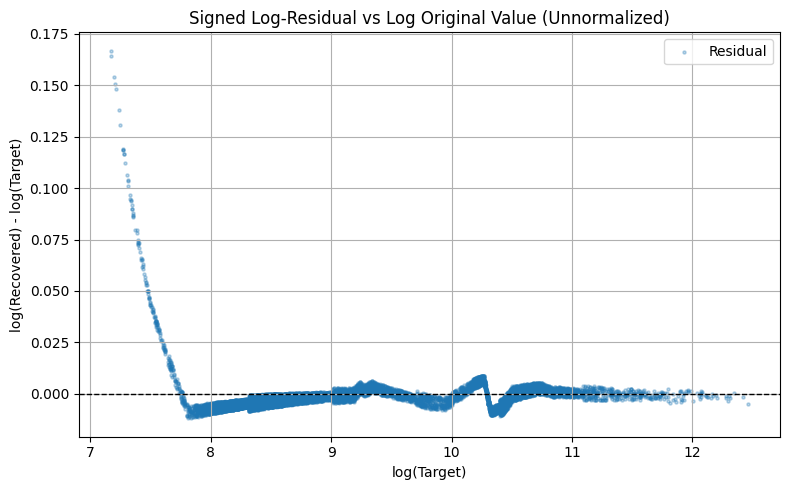

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
sys.path.append("..")  # Add parent directory to Python path
from plotting import plot_log_residual_contour

def log_mse(y, yhat, eps=1e-8):
    return F.mse_loss(torch.log(y + eps), torch.log(yhat + eps))

# ----- 1. Histogram Comparison -----
model.eval()
with torch.no_grad():
    recovered_norm = model(x_source_tensor).cpu().numpy()

# Un-normalise arrays before plotting
recovered = torch.tensor(recovered_norm * std_tgt + mean_tgt)
x_target = torch.tensor(x_target_norm * std_tgt + mean_tgt)
x_source = torch.tensor(x_source_norm * std_src + mean_src)

# Compute MSEs
mse_target_source = log_mse(x_target, x_source)
mse_target_recovered = log_mse(x_target, recovered)    
print(f"MSE (Target vs Source): {mse_target_source:4e}")
print(f"MSE (Target vs Recovered): {mse_target_recovered:4e}")

plt.figure(figsize=(8, 5))
plt.hist(x_target, bins=500, alpha=0.5, label="Target (unnormalized)")
plt.hist(recovered, bins=500, alpha=0.6, label="Recovered (unnormalized)")
plt.hist(x_source, bins=500, alpha=0.6, label="Source (unnormalized)", histtype='step')
plt.legend()
plt.title("1D Distribution Recovery via Autoencoder (Unnormalized Data)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.xlim(x_target.min(), 3 * std_tgt + mean_tgt)  # Adjust as needed
plt.grid(True)
plt.tight_layout()
plt.show()


# ----- 2. Signed Log-Residual vs Log Original -----
import lovely_tensors as lt
recovered = recovered.squeeze()
fig = plot_log_residual_contour(x_target, recovered, theoretical=False, varname="pt", m=10, offset=0.3, save_path=None)

eps = 1e-8

# Make sure arrays are 1D numpy arrays
x_target_arr = np.array(x_target).reshape(-1)
recovered_arr = np.array(recovered).reshape(-1)

# Valid entries (avoid log of <=0)
valid_mask = (x_target_arr > 0) & (recovered_arr > 0)

log_original = np.log(x_target_arr[valid_mask] + eps)
log_recovered = np.log(recovered_arr[valid_mask] + eps)

signed_log_residual = log_recovered - log_original

plt.figure(figsize=(8, 5))
plt.scatter(log_original, signed_log_residual, alpha=0.3, s=5, label="Residual")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Signed Log-Residual vs Log Original Value (Unnormalized)")
plt.xlabel("log(Target)")
plt.ylabel("log(Recovered) - log(Target)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()